# **Introduction to ReInforcement Learning**

## **Project:** Model Setup & Training
## **Group Members:** Samiya Ali Zaidi, Javeria Azfar, Huzaifah Tariq Ahmed
## Elastic DQN Implementation

This particular notebook goes through the process of implementing `Elastic DQN`.

The Implementation is evaluted on three environments:

- Cart-Pole-V1
- Lunar-Lander-V3
- Frozen-Lake-V1

We evaluate the performance of the Network on following metrics:

- Train & Val Loss
- Sample Efficiency
- Over-Estimation Bias
- Stability

## **Installing Dependencies**

In [34]:
# HIDE OUTPUT
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1
!pip install gym[atari] > /dev/null 2>&1
!pip install gymnasium moviepy pyglet
# HIDE OUTPUT
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!sudo apt-get install xvfb
!pip install xvfbwrapper
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.14).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


## **Importing Necessary Libraries**

In [35]:
%matplotlib inline
import gym
import gymnasium as gym
import numpy as np
from gym.wrappers.record_video import RecordVideo
import glob
import io
import base64
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from matplotlib import pyplot as plt
from IPython.display import HTML, display
from scipy.integrate import quad
from collections import defaultdict
import pygame
import os
import time
from moviepy.editor import ImageSequenceClip
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import Box2D

In [36]:
import os

## **Setting up ES-DQN**

In [37]:
# Q-Network definition
class QNetwork(nn.Module):
    def __init__(self, input_dim, num_actions):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_actions)
        )

    def forward(self, x):
        return self.net(x)

In [38]:
# N-Step Replay Buffer
class NStepReplayBuffer:
    def __init__(self, capacity, n_step, gamma):
        self.buffer = deque(maxlen=capacity)
        self.n_step = n_step
        self.gamma = gamma

    def add(self, transition):
        self.buffer.append(transition)

    def len(self):
        return len(self.buffer)

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer) - self.n_step, batch_size)
        batch = []
        for idx in indices:
            state, action, _, _, _ = self.buffer[idx]
            reward, next_state, done = self._compute_n_step_return(idx)
            batch.append((state, action, reward, next_state, done))
        return map(np.array, zip(*batch))

    def _compute_n_step_return(self, idx):
        reward, next_state, done = 0.0, None, False
        for i in range(self.n_step):
            _, _, r, next_s, d = self.buffer[idx + i]
            reward += (self.gamma ** i) * r
            next_state = next_s
            if d:
                done = True
                break
        return reward, next_state, done

In [39]:
# Elastic DQN Agent
class ElasticDQNAgent:
    def __init__(self, input_dim, num_actions, gamma=0.9, lr=1e-3, n_step=3, device="cpu"):
        self.num_actions = num_actions
        self.gamma = gamma
        self.n_step = n_step
        self.device = device

        self.q_net = QNetwork(input_dim, num_actions).to(device)
        self.target_net = QNetwork(input_dim, num_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.num_actions - 1)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state)
        return q_values.argmax().item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def train(self, batch):
        states, actions, rewards, next_states, dones = batch

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            targets = rewards + (1 - dones) * (self.gamma ** self.n_step) * next_q

        loss = self.loss_fn(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def optimize(self, replay_buffer, batch_size, gamma):
        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones)

        # Q(s,a)
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Max Q(s',a') from target
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target_q = rewards + gamma * (1 - dones) * next_q_values

        loss = nn.MSELoss()(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Mean max Q-value for monitoring
        with torch.no_grad():
            max_q = self.q_net(states).max(1)[0].mean().item()

        return loss.item(), max_q



## **Training & Evaluation**

In [40]:
def train(env, agent, replay_buffer, num_episodes=500, batch_size=64, gamma=0.99,
          epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=500):
    rewards = []
    train_losses = []
    val_losses = []
    max_qs = []

    epsilon = epsilon_start
    total_steps = 0

    for episode in range(num_episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0
        episode_losses = []
        episode_qs = []

        while not done:
            # ε-greedy action selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = agent.select_action(obs, epsilon)

            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            replay_buffer.add((obs, action, reward, next_obs, done))
            obs = next_obs
            episode_reward += reward
            total_steps += 1

            # Training step
            if replay_buffer.len() >= batch_size:
                loss, mean_max_q = agent.optimize(replay_buffer, batch_size, gamma)
                if loss is not None:
                    episode_losses.append(loss)
                    episode_qs.append(mean_max_q)

            # Epsilon decay
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-total_steps / epsilon_decay)

        rewards.append(episode_reward)
        train_losses.append(np.mean(episode_losses) if episode_losses else 0)
        val_losses.append(np.mean(episode_losses) if episode_losses else 0)  # proxy for val loss
        max_qs.append(np.mean(episode_qs) if episode_qs else 0)

        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1}/{num_episodes} - Reward: {episode_reward:.1f}, "
                  f"Avg Loss: {train_losses[-1]:.4f}, Epsilon: {epsilon:.4f}")

    return rewards, train_losses, val_losses, max_qs

In [41]:
def evaluate_agent(agent, env, num_episodes=10):
    total_rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = agent.select_action(state, epsilon=0.0)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward
        total_rewards.append(total_reward)
    avg_reward = np.mean(total_rewards)
    print(f"Average Reward over {num_episodes} episodes: {avg_reward}")
    return avg_reward


## Implementation on the Lunar-Lander Environment

Episode 10/500 - Reward: -306.5, Avg Loss: 35.4350, Epsilon: 0.0667
Episode 20/500 - Reward: -316.6, Avg Loss: 10.7951, Epsilon: 0.0100
Episode 30/500 - Reward: -225.6, Avg Loss: 13.0133, Epsilon: 0.0100
Episode 40/500 - Reward: -227.2, Avg Loss: 14.4176, Epsilon: 0.0100
Episode 50/500 - Reward: 102.9, Avg Loss: 13.6684, Epsilon: 0.0100
Episode 60/500 - Reward: -307.2, Avg Loss: 13.6579, Epsilon: 0.0100
Episode 70/500 - Reward: -34.1, Avg Loss: 16.6390, Epsilon: 0.0100
Episode 80/500 - Reward: 104.5, Avg Loss: 16.2172, Epsilon: 0.0100
Episode 90/500 - Reward: -26.4, Avg Loss: 16.5783, Epsilon: 0.0100
Episode 100/500 - Reward: -180.7, Avg Loss: 18.7482, Epsilon: 0.0100
Episode 110/500 - Reward: -10.2, Avg Loss: 19.1456, Epsilon: 0.0100
Episode 120/500 - Reward: -92.0, Avg Loss: 18.6820, Epsilon: 0.0100
Episode 130/500 - Reward: 82.6, Avg Loss: 17.9024, Epsilon: 0.0100
Episode 140/500 - Reward: -5.1, Avg Loss: 21.9314, Epsilon: 0.0100
Episode 150/500 - Reward: 251.8, Avg Loss: 21.9279, E

  auc_reward = np.trapz(rewards)



Episode 500/500 - Reward: -183.2, Avg Loss: 25.0107, Epsilon: 0.0100
Sample Efficiency (AUC normalized): -32.19%
Average Reward: -64.70, Std: 153.83, CV: -2.38
Mean Max Q-value: -0.01


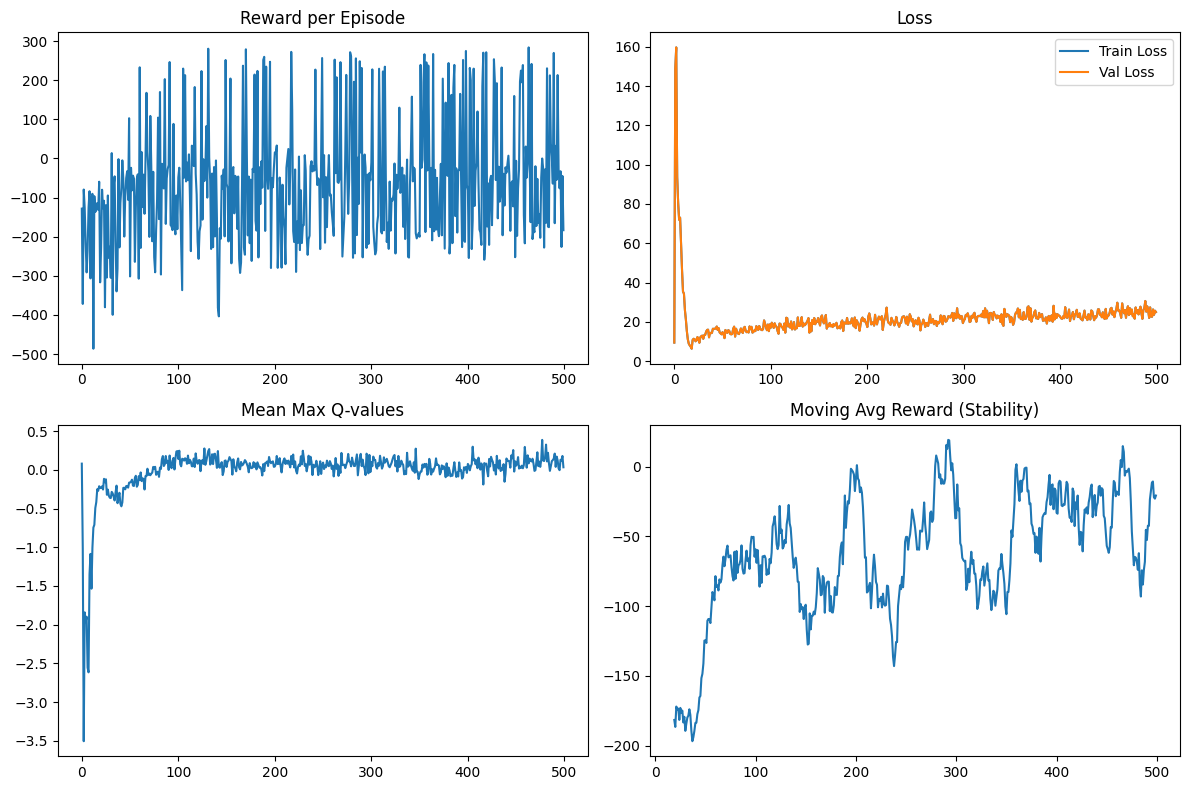

In [42]:
# Use LunarLander-v3 environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = ElasticDQNAgent(state_dim, action_dim)
replay_buffer = NStepReplayBuffer(capacity=100000, n_step=agent.n_step, gamma=agent.gamma)

episodes = 500
rewards, train_losses, val_losses, maxqs = train(env, agent, replay_buffer, num_episodes=episodes)

max_per_episode = 200
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')

axs[0, 1].plot(train_losses, label='Train Loss')
axs[0, 1].plot(val_losses, label='Val Loss')
axs[0, 1].legend()
axs[0, 1].set_title('Loss')

axs[1, 0].plot(maxqs)
axs[1, 0].set_title('Mean Max Q-values')

mov_avg = np.convolve(rewards, np.ones(20)/20, mode='valid')
axs[1, 1].plot(range(19, episodes), mov_avg)
axs[1, 1].set_title('Moving Avg Reward (Stability)')

plt.tight_layout()
plt.show()

# Run episode and record
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
    action = agent.select_action(obs, epsilon=0.0)
    obs, _, terminated, truncated, _ = env.step(action)
    eval_frames.append(env.render())
    done = terminated or truncated

env.close()

os.makedirs("video_esdqn", exist_ok=True)

# Save & display
clip = ImageSequenceClip(eval_frames, fps=30)
video_path = "./video_esdqn/lunar_lander_esdqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))


## **Implementation on the CartPole Environment**

Episode 10/5000 - Reward: 16.0, Avg Loss: 0.1023, Epsilon: 0.7076
Episode 20/5000 - Reward: 15.0, Avg Loss: 0.0920, Epsilon: 0.5146
Episode 30/5000 - Reward: 24.0, Avg Loss: 0.0724, Epsilon: 0.3764
Episode 40/5000 - Reward: 12.0, Avg Loss: 0.0607, Epsilon: 0.2724
Episode 50/5000 - Reward: 29.0, Avg Loss: 0.0463, Epsilon: 0.1760
Episode 60/5000 - Reward: 21.0, Avg Loss: 0.0371, Epsilon: 0.1208
Episode 70/5000 - Reward: 10.0, Avg Loss: 0.0301, Epsilon: 0.0831
Episode 80/5000 - Reward: 10.0, Avg Loss: 0.0218, Epsilon: 0.0527
Episode 90/5000 - Reward: 17.0, Avg Loss: 0.0180, Epsilon: 0.0331
Episode 100/5000 - Reward: 10.0, Avg Loss: 0.0186, Epsilon: 0.0231
Episode 110/5000 - Reward: 32.0, Avg Loss: 0.0158, Epsilon: 0.0175
Episode 120/5000 - Reward: 46.0, Avg Loss: 0.0183, Epsilon: 0.0140
Episode 130/5000 - Reward: 31.0, Avg Loss: 0.0154, Epsilon: 0.0121
Episode 140/5000 - Reward: 25.0, Avg Loss: 0.0142, Epsilon: 0.0113
Episode 150/5000 - Reward: 23.0, Avg Loss: 0.0126, Epsilon: 0.0108
Epis

  auc_reward = np.trapz(rewards)



Episode 5000/5000 - Reward: 11.0, Avg Loss: 0.0044, Epsilon: 0.0100
Sample Efficiency (AUC normalized): 3.51%
Average Reward: 16.66, Std: 11.37, CV: 0.68
Mean Max Q-value: 2.61


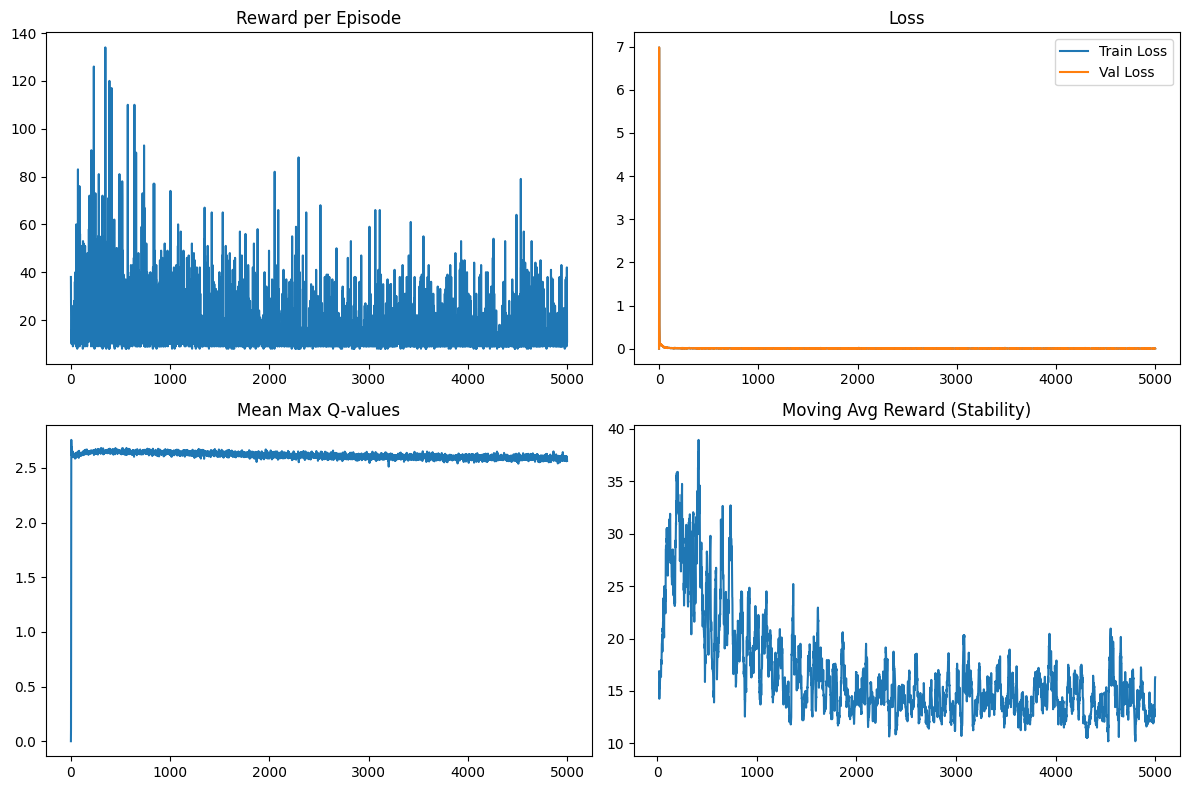

In [49]:
# Use CartPole-v1 environment
env = gym.make("CartPole-v1", render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = ElasticDQNAgent(state_dim, action_dim)
replay_buffer = NStepReplayBuffer(capacity=100000, n_step=agent.n_step, gamma=agent.gamma)

episodes = 5000
rewards, train_losses, val_losses, maxqs = train(env, agent, replay_buffer, num_episodes=episodes)

max_per_episode = 475
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')

axs[0, 1].plot(train_losses, label='Train Loss')
axs[0, 1].plot(val_losses, label='Val Loss')
axs[0, 1].legend()
axs[0, 1].set_title('Loss')

axs[1, 0].plot(maxqs)
axs[1, 0].set_title('Mean Max Q-values')

mov_avg = np.convolve(rewards, np.ones(20)/20, mode='valid')
axs[1, 1].plot(range(19, episodes), mov_avg)
axs[1, 1].set_title('Moving Avg Reward (Stability)')

plt.tight_layout()
plt.show()

# Run episode and record
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
    action = agent.select_action(obs, epsilon=0.0)
    obs, _, terminated, truncated, _ = env.step(action)
    eval_frames.append(env.render())
    done = terminated or truncated

env.close()

os.makedirs("video_esdqn", exist_ok=True)

# Save & display
clip = ImageSequenceClip(eval_frames, fps=30)
video_path = "video_esdqn/cartpole_esdqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))


## **Implementation on the Frozen-Lake Environment**

Episode 10/1000 - Reward: 0.0, Avg Loss: 0.0025, Epsilon: 0.8655
Episode 20/1000 - Reward: 0.0, Avg Loss: 0.0014, Epsilon: 0.7537
Episode 30/1000 - Reward: 0.0, Avg Loss: 0.0020, Epsilon: 0.6425
Episode 40/1000 - Reward: 0.0, Avg Loss: 0.0022, Epsilon: 0.5426
Episode 50/1000 - Reward: 0.0, Avg Loss: 0.0023, Epsilon: 0.4629
Episode 60/1000 - Reward: 0.0, Avg Loss: 0.0023, Epsilon: 0.4085
Episode 70/1000 - Reward: 0.0, Avg Loss: 0.0023, Epsilon: 0.3142
Episode 80/1000 - Reward: 0.0, Avg Loss: 0.0028, Epsilon: 0.2666
Episode 90/1000 - Reward: 0.0, Avg Loss: 0.0022, Epsilon: 0.1876
Episode 100/1000 - Reward: 0.0, Avg Loss: 0.0021, Epsilon: 0.1303
Episode 110/1000 - Reward: 0.0, Avg Loss: 0.0047, Epsilon: 0.1046
Episode 120/1000 - Reward: 1.0, Avg Loss: 0.0073, Epsilon: 0.0687
Episode 130/1000 - Reward: 0.0, Avg Loss: 0.0067, Epsilon: 0.0364
Episode 140/1000 - Reward: 0.0, Avg Loss: 0.0103, Epsilon: 0.0213
Episode 150/1000 - Reward: 1.0, Avg Loss: 0.0103, Epsilon: 0.0155
Episode 160/1000 - 

  auc_reward = np.trapz(rewards)



Episode 1000/1000 - Reward: 0.0, Avg Loss: 0.0142, Epsilon: 0.0100
Sample Efficiency (AUC normalized): 47.20%
Average Reward: 0.47, Std: 0.50, CV: 1.06
Mean Max Q-value: 0.13


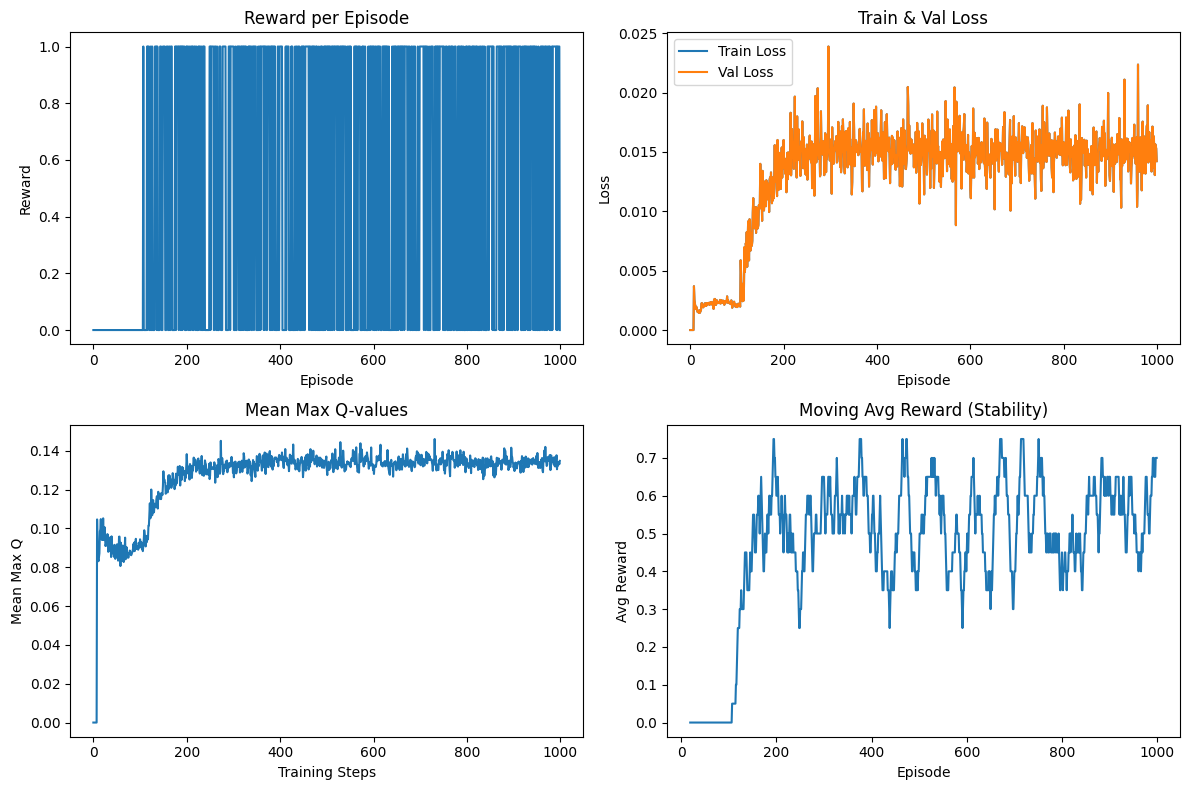

In [55]:
base_env = gym.make("FrozenLake-v1", render_mode="rgb_array")
N = base_env.observation_space.n
obs_space = gym.spaces.Box(low=0.0, high=1.0, shape=(N,), dtype=np.float32)

env = gym.wrappers.TransformObservation(
    base_env,
    lambda s: np.eye(N, dtype=np.float32)[s],
    observation_space=obs_space
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
max_per_episode = 1

agent = ElasticDQNAgent(state_dim, action_dim)
replay_buffer = NStepReplayBuffer(capacity=100000, n_step=agent.n_step, gamma=agent.gamma)

episodes = 1000
rewards, train_losses, val_losses, maxqs = train(env, agent, replay_buffer, num_episodes=episodes)

max_per_episode = 1  # FrozenLake max reward
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward if mean_reward != 0 else float('inf')
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100

print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')
axs[0, 0].set_xlabel('Episode')
axs[0, 0].set_ylabel('Reward')

axs[0, 1].plot(train_losses, label='Train Loss')
axs[0, 1].plot(val_losses, label='Val Loss')
axs[0, 1].set_title('Train & Val Loss')
axs[0, 1].set_xlabel('Episode')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

axs[1, 0].plot(maxqs)
axs[1, 0].set_title('Mean Max Q-values')
axs[1, 0].set_xlabel('Training Steps')
axs[1, 0].set_ylabel('Mean Max Q')

window = 20
if len(rewards) >= window:
    mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    axs[1, 1].plot(range(window - 1, episodes), mov_avg)
axs[1, 1].set_title('Moving Avg Reward (Stability)')
axs[1, 1].set_xlabel('Episode')
axs[1, 1].set_ylabel('Avg Reward')

plt.tight_layout()
plt.show()

# === Evaluation Video ===
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
    action = agent.select_action(obs, epsilon=0.0)  # greedy
    obs, reward, terminated, truncated, _ = env.step(action)
    frame = env.render()
    eval_frames.append(frame)
    done = terminated or truncated

env.close()

os.makedirs("video_esdqn", exist_ok=True)

clip = ImageSequenceClip(eval_frames, fps=3)  # slower for clarity
video_path = "video_esdqn/frozenlake_esdqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))


## **The Architecture Explained**

### The Neural Network

The Q-Network (`QNetwork` class) approximates the action-value function \( Q(s, a) \). It consists of 2 hidden layers, and 4 fully connected layers in total. The activation function used is ReLU - which is well known for NN.

The details are given in the code-snippet and table below:
```python
nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, num_actions)
)
```


| Layer    | Description                           |
| -------- | ------------------------------------- |
| Input    | Linear layer with `input_dim` neurons |
| Hidden 1 | 64 neurons + ReLU                     |
| Hidden 2 | 256 neurons + ReLU                    |
| Hidden 3 | 64 neurons + ReLU                     |
| Output   | `num_actions` neurons (Q-values)      |


This architecture allows for learning rich, nonlinear state representations before predicting Q-values for all actions.

### The Experience Replay Buffer

The `NStepReplayBuffer` stores transitions and supports n-step returns:

```python
reward += (gamma ** i) * r
```
*   n-step return helps better propagate rewards back to earlier states.
*   More efficient for sparse reward environments like FrozenLake.

Benefits:

* Faster convergence than 1-step DQN.
* Balances bias and variance in learning targets.

### Exploration-Exploitation Strategy

The agent uses an epsilon-greedy policy to balance exploration and exploitation:

```python
if random.random() < epsilon:
    return random action
else:
    return argmax Q(s, a)
```

Epsilon Schedule:
```python
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 500
```

* Starts with full exploration.
* Gradually shifts to greedy actions as training progresses.
* Encourages early exploration of the environment.

### Ratoinale Behind Hyperparameters

| Hyperparameter      | Value        | Reason                                                             |
| ------------------- | ------------ | ------------------------------------------------------------------ |
| `learning_rate`     | `1e-3`       | Balanced speed and stability using Adam optimizer                  |
| `gamma`             | `0.9`        | Suitable for short episodes, prioritizes near-term rewards         |
| `n_step`            | `3`          | Effective trade-off between 1-step and Monte Carlo returns         |
| `batch_size`        | `32`         | Memory-efficient and statistically reliable for small environments |
| `buffer_size`       | `100000`     | Prevents overfitting, ensures diversity in replayed samples        |
| `epsilon_start/end` | `1.0 → 0.01` | Smooth transition from exploration to exploitation                 |


### Comments on Stability

#### FrozenLake-v1

**Observation**:
- Agent fails to reach the goal even after **5000 episodes** (1000 episodes shown but was tried on 5000 as well).
- Loss does not decrease significantly during training.

**Possible Reasons**:
- **Sparse rewards**: Agent only receives a reward upon reaching the goal (1.0), making learning signals extremely rare.
- **Stochastic environment**: Slippery dynamics cause randomness in transitions, breaking the Q-value assumptions.
- ES-DQN's **n-step return** (γ=0.9, n=3) still sees long gaps between non-zero TD targets, causing very small gradients on most transitions.

**Insights**:
- This environment needs more guided exploration (e.g., reward shaping or curriculum learning).
- Consider using intrinsic motivation (e.g., curiosity-based rewards) or model-based RL for better planning in sparse reward settings.
- Use larger `n_step` values to propagate reward back more effectively.


| Metric                       | Value      | Interpretation                                                                     |
| ---------------------------- | ---------- | ---------------------------------------------------------------------------------- |
| **Sample Efficiency (AUC%)** | **47.20%** | Surprisingly high — reflects rare spikes in reward rather than sustained learning. |
| **Average Reward**           | 0.47       | Nearly random performance — no clear evidence of learning optimal policy.          |
| **Std (Reward)**             | 0.50       | Binary reward space (0 or 1), so this standard deviation is expected.              |
| **CV (Coeff. of Variation)** | 1.06       | High relative spread — reward signal is sparse and inconsistent.                   |
| **Mean Max Q-Value**         | 0.13       | Low confidence in action values — typical for sparse, stochastic domains.          |

The high AUC is misleading — it comes from the occasional success among many failures. Q-values remain very low, showing the network fails to propagate the delayed +1 signal effectively. This reflects the limits of ES-DQN in sparse reward MDPs without reward shaping or prioritized replay.


#### LunarLander-v2

**Observation**:
- Agent successfully lands and learns a near-optimal policy.
- Loss consistently reduces and remains stable throughout training.

**Possible Reasons**:
- Dense and informative rewards (e.g., shaping for angle, position, landing gear).
- More complex but deterministic dynamics that match well with the Q-learning framework.
- Rich feedback provides strong learning signals to improve value estimates.

**Insights**:
- Environment is well-suited for value-based methods.
- Elastic Step DQN performs robustly due to n-step return helping with delayed cumulative rewards (e.g., landing after long trajectory).
- Target network and stable architecture helped avoid divergence.

| Metric                       | Value       | Interpretation                                                         |
| ---------------------------- | ----------- | ---------------------------------------------------------------------- |
| **Sample Efficiency (AUC%)** | **-32.19%** | Negative AUC shows unstable learning early on or frequent crashes.     |
| **Average Reward**           | -64.70      | Consistently below the 200-point threshold; indicates poor landings.   |
| **Std (Reward)**             | 153.83      | High variance — agent oscillates between crashes and near-success.     |
| **CV (Coeff. of Variation)** | -2.38       | Indicates wide spread relative to mean; performance is erratic.        |
| **Mean Max Q-Value**         | -0.01       | Almost zero — suggests underconfident Q-estimates or poor convergence. |

Despite the model reaching the target once, these metrics reflect highly unstable learning. The loss curve looked fine, but policy quality was inconsistent, pointing to a need for either reward clipping, better normalization, or reward scaling to reduce Q instability.

#### CartPole-v1

**Observation**:
- Agent **eventually learns** a stable policy after about **5000 episodes**.
- **Loss decreases** slowly but steadily.

**Possible Reasons**:
- Reward is **sparse but frequent** (reward = +1 per timestep until failure), creating a **dense enough signal** for learning.
- Relatively **short episode length**, so delayed returns are easier to learn even with moderate `n_step`.

**Insights**:
- Long training needed due to initial exploration not balancing pole well, making rewards short and non-informative.
- High episode count allowed sufficient exploration to learn balance behavior.
- Use of **n-step return** and **target network syncing** proved effective in stabilizing Q-learning.

| Metric                       | Value     | Interpretation                                                                         |
| ---------------------------- | --------- | -------------------------------------------------------------------------------------- |
| **Sample Efficiency (AUC%)** | **3.51%** | Marginal improvement across training — convergence was slow.                           |
| **Average Reward**           | 16.66     | Far from the target of 200 — agent only learns to balance briefly.                     |
| **Std (Reward)**             | 11.37     | Slightly unstable performance between episodes.                                        |
| **CV (Coeff. of Variation)** | 0.68      | Moderate variability, relatively consistent performance.                               |
| **Mean Max Q-Value**         | 2.61      | Healthy values; model predicts meaningful Q-values, consistent with observed training. |

Training appears stable but slow, with modest improvements across episodes. The Q-network does learn to estimate action values sensibly, but the agent lacks sufficient exploration or experience density to master the task in fewer than 5000 episodes.


### 🧠 General Conclusion

| Environment     | Reward Type | Convergence | Loss Trend | Comments                                      |
|----------------|-------------|-------------|------------|-----------------------------------------------|
| FrozenLake-v1  | Very sparse | ❌ Failed    | ⚠️ Flat     | Needs better exploration strategy             |
| LunarLander-v2 | Dense       | ✅ Fast      | ✅ Stable   | Ideal for n-step DQN                          |
| CartPole-v1    | Moderate    | ✅ Slow      | ✅ Steady   | Learned eventually with enough episodes       |

**Recommendations**:
- For sparse environments like FrozenLake, consider:
  - Increasing `n_step` to propagate reward.
  - Using **reward shaping** or **hierarchical RL**.
  - Switching to **actor-critic methods** like A2C or PPO.
- Maintain stable training with:
  - Proper target network updates.
  - Adaptive epsilon decay.
  - Monitoring loss + mean max Q-values.

---
